# Phase II: quench dynamics of the Hubbard dimer

**Goal.** Prepare the half-filled ground state of an initial Hubbard Hamiltonian $H(U_i)$, suddenly quench the interaction to $U_f$, and study real-time observables under $H(U_f)$.

This notebook establishes two validation levels:

1. exact classical propagation in the full four-spin-orbital Fock space; and
2. a literature regression of the closed-system $U_i/t=100\rightarrow U_f/t=5$ quench in [Zavatti, Bellomia, and Capone, arXiv:2605.18494](https://arxiv.org/abs/2605.18494).

We then approximate the same evolution with a second-order Suzuki--Trotter quantum circuit and quantify its error and convergence. Throughout, $\hbar=1$, so physical time is reported in units of $1/t$.

## 1. Imports and project conventions

The canonical mode order is the project's spin-blocked convention

$$[0\uparrow,1\uparrow,0\downarrow,1\downarrow].$$

Orbital 0 is the least-significant bit in the statevector index. The reusable model code from Phase I fixes all fermionic signs and qubit-ordering conventions.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
from scipy.sparse import SparseEfficiencyWarning

from qiskit import QuantumCircuit
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit.synthesis import SuzukiTrotter

from quantum_hubbard.model import (
    HILBERT_DIMENSION,
    N_SPIN_ORBITALS,
    fermionic_operators,
    hubbard_hamiltonian,
    particle_number_operator,
    solve_particle_sector,
)
from quantum_hubbard.observables import double_occupancy_operator
from quantum_hubbard.operators import pauli_decomposition

warnings.filterwarnings("ignore", category=SparseEfficiencyWarning)
np.set_printoptions(precision=8, suppress=True)
plt.style.use("seaborn-v0_8-whitegrid")

ATOL = 1e-10

## 2. Quench protocol

For the open two-site Hubbard Hamiltonian

$$
H(U)=-t\sum_{\sigma}(c_{0\sigma}^{\dagger}c_{1\sigma}+c_{1\sigma}^{\dagger}c_{0\sigma})+U\sum_{i=0}^{1}n_{i\uparrow}n_{i\downarrow},
$$

we prepare the $N_\uparrow=N_\downarrow=1$ ground state $|\psi_0\rangle$ of $H(U_i)$. At time zero the interaction is changed instantaneously, and

$$|\psi(\tau)\rangle=e^{-iH(U_f)\tau}|\psi_0\rangle.
$$

We write time as $\tau$ here to distinguish it from the hopping amplitude $t$.

In [2]:
hopping = 1.0
u_initial = 100.0
u_final = 5.0
num_particles = 2

H_initial = hubbard_hamiltonian(t=hopping, u=u_initial)
H_final = hubbard_hamiltonian(t=hopping, u=u_final)
initial_solution = solve_particle_sector(H_initial, num_particles=num_particles)
psi_initial = initial_solution.ground_state

assert np.isclose(np.linalg.norm(psi_initial), 1.0, atol=ATOL)
assert np.isclose(
    np.vdot(psi_initial, H_initial @ psi_initial).real,
    initial_solution.ground_energy,
    atol=ATOL,
)

print(f"Initial ground-state energy: {initial_solution.ground_energy:.10f}")
print(f"Quench: U_i/t = {u_initial / hopping:g} -> U_f/t = {u_final / hopping:g}")

Initial ground-state energy: -0.0399840128
Quench: U_i/t = 100 -> U_f/t = 5


## 3. Exact classical propagation

Diagonalizing $H_f=H(U_f)$ once gives

$$|\psi(\tau)\rangle=\sum_n e^{-iE_n\tau}|E_n\rangle\langle E_n|\psi_0\rangle.
$$

For this 16-dimensional Fock space (or six-dimensional fixed-$N$ sector), this is effectively exact and serves as the numerical reference for every approximate evolution.

In [3]:
def exact_trajectory(hamiltonian, initial_state, times):
    energies, eigenvectors = np.linalg.eigh(hamiltonian)
    coefficients = eigenvectors.conj().T @ initial_state
    return np.asarray(
        [
            eigenvectors @ (np.exp(-1j * energies * time) * coefficients)
            for time in times
        ]
    )


def trajectory_expectation(states, operator):
    values = np.einsum("ti,ij,tj->t", states.conj(), operator, states)
    assert np.max(np.abs(values.imag)) < ATOL
    return values.real


omega = np.sqrt(u_final**2 + 16 * hopping**2)
oscillation_period = 2 * np.pi / omega
periods_to_show = 4
steps_per_period = 80
num_steps = periods_to_show * steps_per_period
times = np.linspace(0.0, periods_to_show * oscillation_period, num_steps + 1)
exact_states = exact_trajectory(H_final, psi_initial, times)

print(f"Predicted angular frequency: omega = {omega:.8f}")
print(f"Predicted period: 2 pi / omega = {oscillation_period:.8f}")

Predicted angular frequency: omega = 6.40312424
Predicted period: 2 pi / omega = 0.98126869


## 4. Independent analytic dimer check

The paper solves the half-filled dimer analytically. Only its two singlet eigenstates participate in this quench, so

$$|\psi(\tau)\rangle=\alpha e^{-iE_-\tau}|\psi_-(U_f)\rangle+\beta e^{-iE_+\tau}|\psi_+(U_f)\rangle,$$

with $E_\pm=U_f/2\pm\tfrac12\sqrt{U_f^2+16t^2}$. The occupation-basis signs below are adapted to this project's spin-blocked fermionic mode ordering; physical observables are unchanged.

In [4]:
def basis_ket(index):
    ket = np.zeros(HILBERT_DIMENSION, dtype=complex)
    ket[index] = 1.0
    return ket


def analytic_singlet(u, branch):
    sign = 1.0 if branch == "minus" else -1.0
    delta = u / (4 * hopping) + sign * np.sqrt(1 + (u / (4 * hopping)) ** 2)
    normalization = np.sqrt(2 * (1 + delta**2))
    return (
        basis_ket(5)
        + delta * basis_ket(6)
        + delta * basis_ket(9)
        + basis_ket(10)
    ) / normalization


psi_initial_analytic = analytic_singlet(u_initial, "minus")
psi_minus_final = analytic_singlet(u_final, "minus")
psi_plus_final = analytic_singlet(u_final, "plus")
energy_minus = (u_final - omega) / 2
energy_plus = (u_final + omega) / 2
alpha = np.vdot(psi_minus_final, psi_initial_analytic)
beta = np.vdot(psi_plus_final, psi_initial_analytic)
analytic_states = np.asarray(
    [
        alpha * np.exp(-1j * energy_minus * time) * psi_minus_final
        + beta * np.exp(-1j * energy_plus * time) * psi_plus_final
        for time in times
    ]
)

initial_fidelity = abs(np.vdot(psi_initial_analytic, psi_initial)) ** 2
state_fidelities = np.abs(np.einsum("ti,ti->t", analytic_states.conj(), exact_states)) ** 2
assert np.isclose(initial_fidelity, 1.0, atol=ATOL)
assert np.allclose(state_fidelities, 1.0, atol=ATOL)
assert np.isclose(energy_plus - energy_minus, omega, atol=ATOL)

print(f"Initial-state analytic fidelity: {initial_fidelity:.12f}")
print(f"Minimum analytic/exact trajectory fidelity: {state_fidelities.min():.12f}")

Initial-state analytic fidelity: 1.000000000000
Minimum analytic/exact trajectory fidelity: 1.000000000000


## 5. Double occupancy and spin correlations

The repository observable is the **total** double occupancy $D_0+D_1$. The paper instead plots the **per-site** value

$$\langle d(\tau)\rangle=\frac12\sum_{i=0}^{1}\langle n_{i\uparrow}n_{i\downarrow}\rangle_\tau.
$$

We retain both definitions and also measure the longitudinal equal-time spin correlation

$$C_{01}^{zz}(\tau)=\langle S_0^zS_1^z\rangle_\tau,\qquad S_i^z=\tfrac12(n_{i\uparrow}-n_{i\downarrow}).$$

In [5]:
_, _, number_operators = fermionic_operators()
D_0 = number_operators[0] @ number_operators[2]
D_1 = number_operators[1] @ number_operators[3]
D_total = double_occupancy_operator()
D_per_site = 0.5 * D_total
S_z_0 = 0.5 * (number_operators[0] - number_operators[2])
S_z_1 = 0.5 * (number_operators[1] - number_operators[3])
C_zz = S_z_0 @ S_z_1
S_z_total = S_z_0 + S_z_1
N_total = particle_number_operator()

double_0_exact = trajectory_expectation(exact_states, D_0)
double_1_exact = trajectory_expectation(exact_states, D_1)
double_total_exact = trajectory_expectation(exact_states, D_total)
double_per_site_exact = trajectory_expectation(exact_states, D_per_site)
czz_exact = trajectory_expectation(exact_states, C_zz)

assert np.allclose(double_0_exact, double_1_exact, atol=ATOL)
assert np.allclose(double_total_exact, double_0_exact + double_1_exact, atol=ATOL)
assert np.allclose(double_per_site_exact, 0.5 * double_total_exact, atol=ATOL)
assert np.isclose(double_per_site_exact[0], double_per_site_exact[steps_per_period], atol=ATOL)

print(
    "Per-site double-occupancy range: "
    f"[{double_per_site_exact.min():.8f}, {double_per_site_exact.max():.8f}]"
)

Per-site double-occupancy range: [0.00019976, 0.18541750]


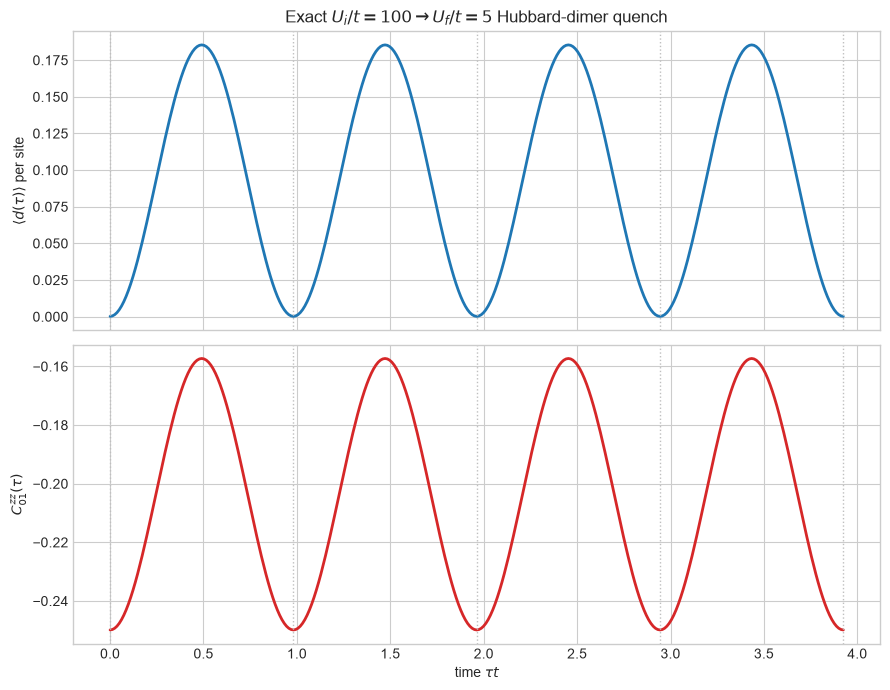

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
axes[0].plot(times, double_per_site_exact, color="tab:blue", lw=2)
axes[0].set_ylabel(r"$\langle d(\tau)\rangle$ per site")
axes[0].set_title(r"Exact $U_i/t=100\rightarrow U_f/t=5$ Hubbard-dimer quench")

axes[1].plot(times, czz_exact, color="tab:red", lw=2)
axes[1].set_xlabel(r"time $\tau t$")
axes[1].set_ylabel(r"$C_{01}^{zz}(\tau)$")

for axis in axes:
    for period_index in range(periods_to_show + 1):
        axis.axvline(period_index * oscillation_period, color="0.75", ls=":", lw=1)
fig.tight_layout()
plt.show()

## 6. Exact-evolution acceptance checks

Unitary evolution preserves the norm. Because the Hamiltonian is time independent after the sudden quench, $\langle H_f\rangle$ is also constant. Particle number and total $S^z$ remain fixed because both commute with $H_f$.

In [7]:
norms = np.sum(np.abs(exact_states) ** 2, axis=1)
energies = trajectory_expectation(exact_states, H_final)
particle_numbers = trajectory_expectation(exact_states, N_total)
total_spin_z = trajectory_expectation(exact_states, S_z_total)

assert np.allclose(norms, 1.0, atol=ATOL)
assert np.allclose(energies, energies[0], atol=ATOL)
assert np.allclose(particle_numbers, num_particles, atol=ATOL)
assert np.allclose(total_spin_z, 0.0, atol=ATOL)

print(f"Maximum norm drift: {np.max(np.abs(norms - 1)):.3e}")
print(f"Maximum post-quench energy drift: {np.max(np.abs(energies - energies[0])):.3e}")
print(f"Maximum particle-number drift: {np.max(np.abs(particle_numbers - num_particles)):.3e}")
print(f"Maximum total-Sz drift: {np.max(np.abs(total_spin_z)):.3e}")

Maximum norm drift: 1.332e-15
Maximum post-quench energy drift: 7.078e-16
Maximum particle-number drift: 2.442e-15
Maximum total-Sz drift: 9.913e-34


## 7. Trotterized quantum evolution

### Why a product formula is needed

After the Jordan--Wigner mapping, the qubit Hamiltonian is a sum of Pauli strings,

$$H_f=\sum_{\ell=1}^{m}h_\ell P_\ell,$$

where each $P_\ell$ is a tensor product of $I$, $X$, $Y$, and $Z$. If all Pauli terms commuted, the short-time propagator would factor exactly as

$$e^{-iH_f\Delta\tau}=\prod_{\ell=1}^{m}e^{-ih_\ell P_\ell\Delta\tau}.$$

The Hubbard hopping and interaction terms do **not** all commute, so this equality is generally false. A product formula replaces the exponential of the sum by an ordered sequence of exponentials that can be implemented as quantum gates.

### Second-order Suzuki formula

For the simple split $H=A+B$, the symmetric second-order formula is

$$S_2(\Delta\tau)=e^{-iA\Delta\tau/2}e^{-iB\Delta\tau}e^{-iA\Delta\tau/2}=e^{-i(A+B)\Delta\tau}+O(\Delta\tau^3).$$

For many Pauli terms, Qiskit uses the corresponding palindromic sequence

$$
S_2(\Delta\tau)=
\left(\prod_{\ell=1}^{m-1}e^{-ih_\ell P_\ell\Delta\tau/2}\right)
e^{-ih_mP_m\Delta\tau}
\left(\prod_{\ell=m-1}^{1}e^{-ih_\ell P_\ell\Delta\tau/2}\right).
$$

The reverse-order second half is what cancels the leading first-order error. To reach a total time $\tau=r\Delta\tau$, the circuit repeats the step $r$ times,

$$e^{-iH_f\tau}\approx [S_2(\Delta\tau)]^r.$$

Each step has local error $O(\Delta\tau^3)$; accumulated over a fixed total time, the global error is $O(\Delta\tau^2)$. This is why halving $\Delta\tau$ should reduce the leading error by approximately a factor of four, as tested in Section 8. The approximation becomes exact when the relevant terms commute.

### From Pauli exponentials to gates

Each factor $e^{-i\theta P_\ell}$ is a Pauli rotation. For example, $e^{-i\theta Z}=R_Z(2\theta)$. A multi-qubit Pauli rotation is implemented by rotating into the appropriate Pauli basis, accumulating the joint parity, applying a $Z$ rotation, and undoing those operations. For this four-qubit Hamiltonian, Qiskit simplifies the factors to **rz**, **rxx**, **ryy**, and **rzz** rotations. The identity term contributes only an unobservable global phase.

In the code below, **reps=1** creates one symmetric Suzuki sequence for a single **time_step**; the Python loop applies that step repeatedly. Calling **decompose()** is essential: it exposes the approximate product-formula circuit. Without decomposition, **Statevector** could apply the abstract **PauliEvolutionGate** through its exact matrix, hiding the Trotter error we intend to measure. The statevector simulator then applies every gate exactly, so the comparison below isolates product-formula error—there is no shot noise or hardware noise yet.

In [8]:
pauli_terms = pauli_decomposition(H_final)
H_qubit = SparsePauliOp.from_list(list(pauli_terms.items()))
assert np.allclose(H_qubit.to_matrix(), H_final, atol=ATOL)


def trotter_trajectory(initial_state, qubit_hamiltonian, time_step, steps, order=2):
    product_formula = SuzukiTrotter(order=order, reps=1)
    evolution_gate = PauliEvolutionGate(
        qubit_hamiltonian, time=time_step, synthesis=product_formula
    )
    step_circuit = QuantumCircuit(N_SPIN_ORBITALS)
    step_circuit.append(evolution_gate, range(N_SPIN_ORBITALS))
    step_circuit = step_circuit.decompose()

    state = Statevector(initial_state)
    states = [state.data.copy()]
    for _ in range(steps):
        state = state.evolve(step_circuit)
        states.append(state.data.copy())
    return np.asarray(states), step_circuit


time_step = times[1] - times[0]
trotter_states, trotter_step_circuit = trotter_trajectory(
    psi_initial, H_qubit, time_step, num_steps
)
double_per_site_trotter = trajectory_expectation(trotter_states, D_per_site)
czz_trotter = trajectory_expectation(trotter_states, C_zz)
double_error = double_per_site_trotter - double_per_site_exact

print(f"Time step: {time_step:.8f}")
print(f"One-step circuit depth: {trotter_step_circuit.depth()}")
print(f"One-step operations: {dict(trotter_step_circuit.count_ops())}")
print(f"Max |double-occupancy error|: {np.max(np.abs(double_error)):.3e}")

Time step: 0.01226586
One-step circuit depth: 15
One-step operations: {'rz': 8, 'rxx': 4, 'ryy': 4, 'rzz': 3}
Max |double-occupancy error|: 1.606e-04


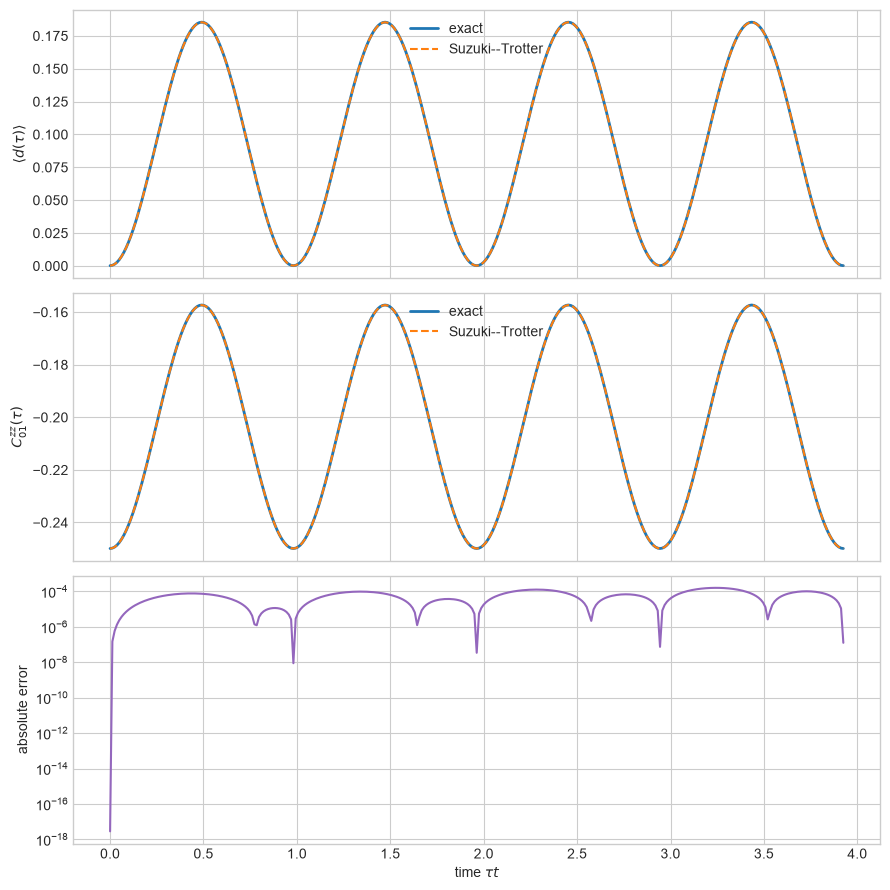

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(9, 9), sharex=True)
axes[0].plot(times, double_per_site_exact, label="exact", lw=2)
axes[0].plot(times, double_per_site_trotter, "--", label="Suzuki--Trotter", lw=1.5)
axes[0].set_ylabel(r"$\langle d(\tau)\rangle$")
axes[0].legend()

axes[1].plot(times, czz_exact, label="exact", lw=2)
axes[1].plot(times, czz_trotter, "--", label="Suzuki--Trotter", lw=1.5)
axes[1].set_ylabel(r"$C_{01}^{zz}(\tau)$")
axes[1].legend()

axes[2].plot(times, np.abs(double_error), color="tab:purple")
axes[2].set_yscale("log")
axes[2].set_xlabel(r"time $\tau t$")
axes[2].set_ylabel("absolute error")
fig.tight_layout()
plt.show()

## 8. Product-formula convergence

A second-order Suzuki formula should have global error $O(\Delta\tau^2)$ at fixed final time. Halving the time step should therefore reduce the leading error by approximately a factor of four. We test this using the maximum per-site double-occupancy error over two physical oscillation periods.

Delta tau = 0.04906343: max error = 1.565262e-03
Delta tau = 0.02453172: max error = 3.933355e-04
Delta tau = 0.01226586: max error = 9.851640e-05
Observed convergence order: 1.9949


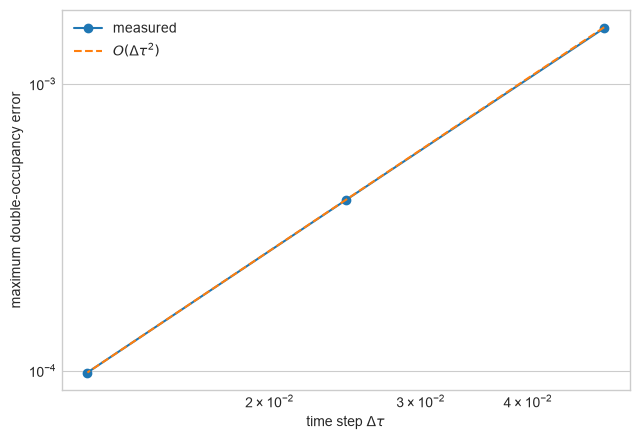

In [10]:
steps_per_period_values = np.array([20, 40, 80])
time_steps = oscillation_period / steps_per_period_values
max_errors = []

for steps_in_period, convergence_dt in zip(steps_per_period_values, time_steps):
    convergence_steps = 2 * int(steps_in_period)
    convergence_times = np.arange(convergence_steps + 1) * convergence_dt
    convergence_exact = exact_trajectory(H_final, psi_initial, convergence_times)
    convergence_trotter, _ = trotter_trajectory(
        psi_initial, H_qubit, convergence_dt, convergence_steps
    )
    exact_d = trajectory_expectation(convergence_exact, D_per_site)
    trotter_d = trajectory_expectation(convergence_trotter, D_per_site)
    max_errors.append(np.max(np.abs(trotter_d - exact_d)))

max_errors = np.asarray(max_errors)
observed_order = np.polyfit(np.log(time_steps), np.log(max_errors), 1)[0]
assert np.all(np.diff(max_errors) < 0)
assert 1.8 < observed_order < 2.2

for dt_value, error in zip(time_steps, max_errors):
    print(f"Delta tau = {dt_value:.8f}: max error = {error:.6e}")
print(f"Observed convergence order: {observed_order:.4f}")

fig, axis = plt.subplots(figsize=(6.5, 4.5))
axis.loglog(time_steps, max_errors, "o-", label="measured")
reference = max_errors[-1] * (time_steps / time_steps[-1]) ** 2
axis.loglog(time_steps, reference, "--", label=r"$O(\Delta\tau^2)$")
axis.set_xlabel(r"time step $\Delta\tau$")
axis.set_ylabel("maximum double-occupancy error")
axis.legend()
fig.tight_layout()
plt.show()

## 9. What has been established

This notebook now provides the Phase II baseline:

- the $H(U_i)$ ground state is prepared in the correct half-filled sector;
- full-matrix propagation agrees with the paper's analytic two-singlet solution;
- the $U_i/t=100\rightarrow U_f/t=5$ per-site double-occupancy oscillation is reproduced with the predicted frequency $\sqrt{U_f^2+16t^2}$;
- norm, post-quench energy, particle number, and total $S^z$ are conserved; and
- the Trotterized qubit evolution converges to the exact result at second order.

Natural next steps are finite-shot observable estimation, circuit-resource reporting after transpilation, noisy simulation, and only then the paper's phenomenological dephasing channel $\Gamma>0$.